# 00_verify_dataset

- Load train and val block tensors; confirm shapes (N, 1, 1024) and manifest lengths match tensor dim 0
- Confirm alpha (clipping threshold) distribution across all blocks is approximately uniform 
- Confirm talker distribution is approximately uniform across train and val blocks
- Confirm that all block avg powers exceed SILENCE_THRESH

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import json
import torch
%matplotlib widget

import sys
sys.path.insert(0, "..")
from config import *

In [2]:
# Load tensors and manifests

train_tensor = torch.load(TRAIN_OUT / "train_blocks.pt", weights_only=True)
val_tensor = torch.load(VAL_OUT / "val_blocks.pt", weights_only=True)

with open(TRAIN_OUT / "train_manifest.json") as f:
    train_manifest = json.load(f)

with open(VAL_OUT / "val_manifest.json") as f:
    val_manifest = json.load(f)

In [3]:
# Check tensor and manifest shapes

print(f"Train tensor shape: {train_tensor.shape}")
print(f"Val tensor shape:   {val_tensor.shape}")
print(f"Train manifest entries: {len(train_manifest)}")
print(f"Val manifest entries:   {len(val_manifest)}")

Train tensor shape: torch.Size([225045, 1, 1024])
Val tensor shape:   torch.Size([28131, 1, 1024])
Train manifest entries: 225045
Val manifest entries:   28131


In [4]:
train_manifest[:5]

[{'block_idx': 0, 'tlkr_id': 587, 'alpha': 0.662542},
 {'block_idx': 1, 'tlkr_id': 2911, 'alpha': 0.381262},
 {'block_idx': 2, 'tlkr_id': 2136, 'alpha': 0.763669},
 {'block_idx': 3, 'tlkr_id': 5192, 'alpha': 0.274883},
 {'block_idx': 4, 'tlkr_id': 5561, 'alpha': 0.205168}]

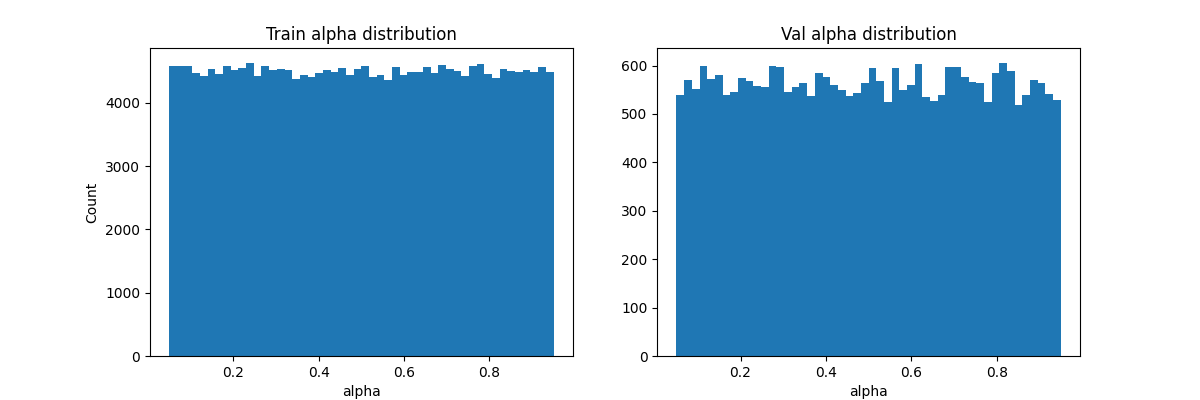

In [5]:
# Inspect alpha distribution

alpha_train = np.array([entry["alpha"] for entry in train_manifest])
alpha_val = np.array([entry["alpha"] for entry in val_manifest])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(alpha_train, bins=50)
axes[0].set_title("Train alpha distribution")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("Count")

axes[1].hist(alpha_val, bins=50)
axes[1].set_title("Val alpha distribution")
axes[1].set_xlabel("alpha")

plt.show()

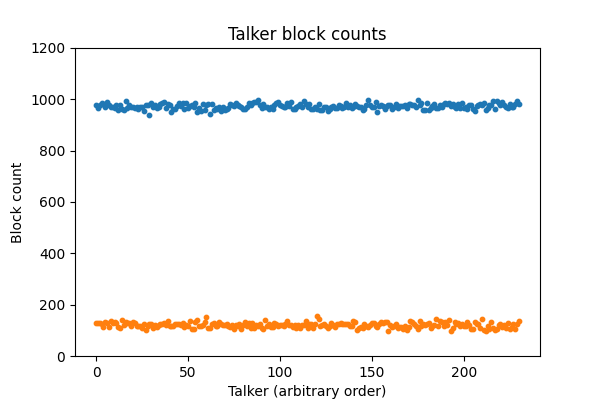

In [13]:
# Inspect talker distribution

tlkr_counts_train = {}
tlkr_counts_val = {}

for entry in train_manifest:
    tlkr_id = entry["tlkr_id"]
    if tlkr_counts_train.get(tlkr_id) is None:
        tlkr_counts_train[tlkr_id] = 0
    else:
        tlkr_counts_train[tlkr_id] += 1
for entry in val_manifest:
    tlkr_id = entry["tlkr_id"]
    if tlkr_counts_val.get(tlkr_id) is None:
        tlkr_counts_val[tlkr_id] = 0
    else:
        tlkr_counts_val[tlkr_id] += 1

train_counts = list(tlkr_counts_train.values())
val_counts = list(tlkr_counts_val.values())

fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(range(len(train_counts)), train_counts, s=10, label="train")
ax.scatter(range(len(val_counts)), val_counts, s=10, label="val")
ax.set_title("Talker block counts")
ax.set_xlabel("Talker (arbitrary order)")
ax.set_ylabel("Block count")
ax.set_ylim([0, 1200])

plt.show()

In [18]:
# Confirm block avg pwr

pwr_train = train_tensor.pow(2).mean(dim=2)
pwr_val = val_tensor.pow(2).mean(dim=2)

print("Min block avg power:")
print(f"    train: {pwr_train.min():>5.3f}")
print(f"      val: {pwr_val.min():>5.3f}")

Min block avg power:
    train: 0.025
      val: 0.025
